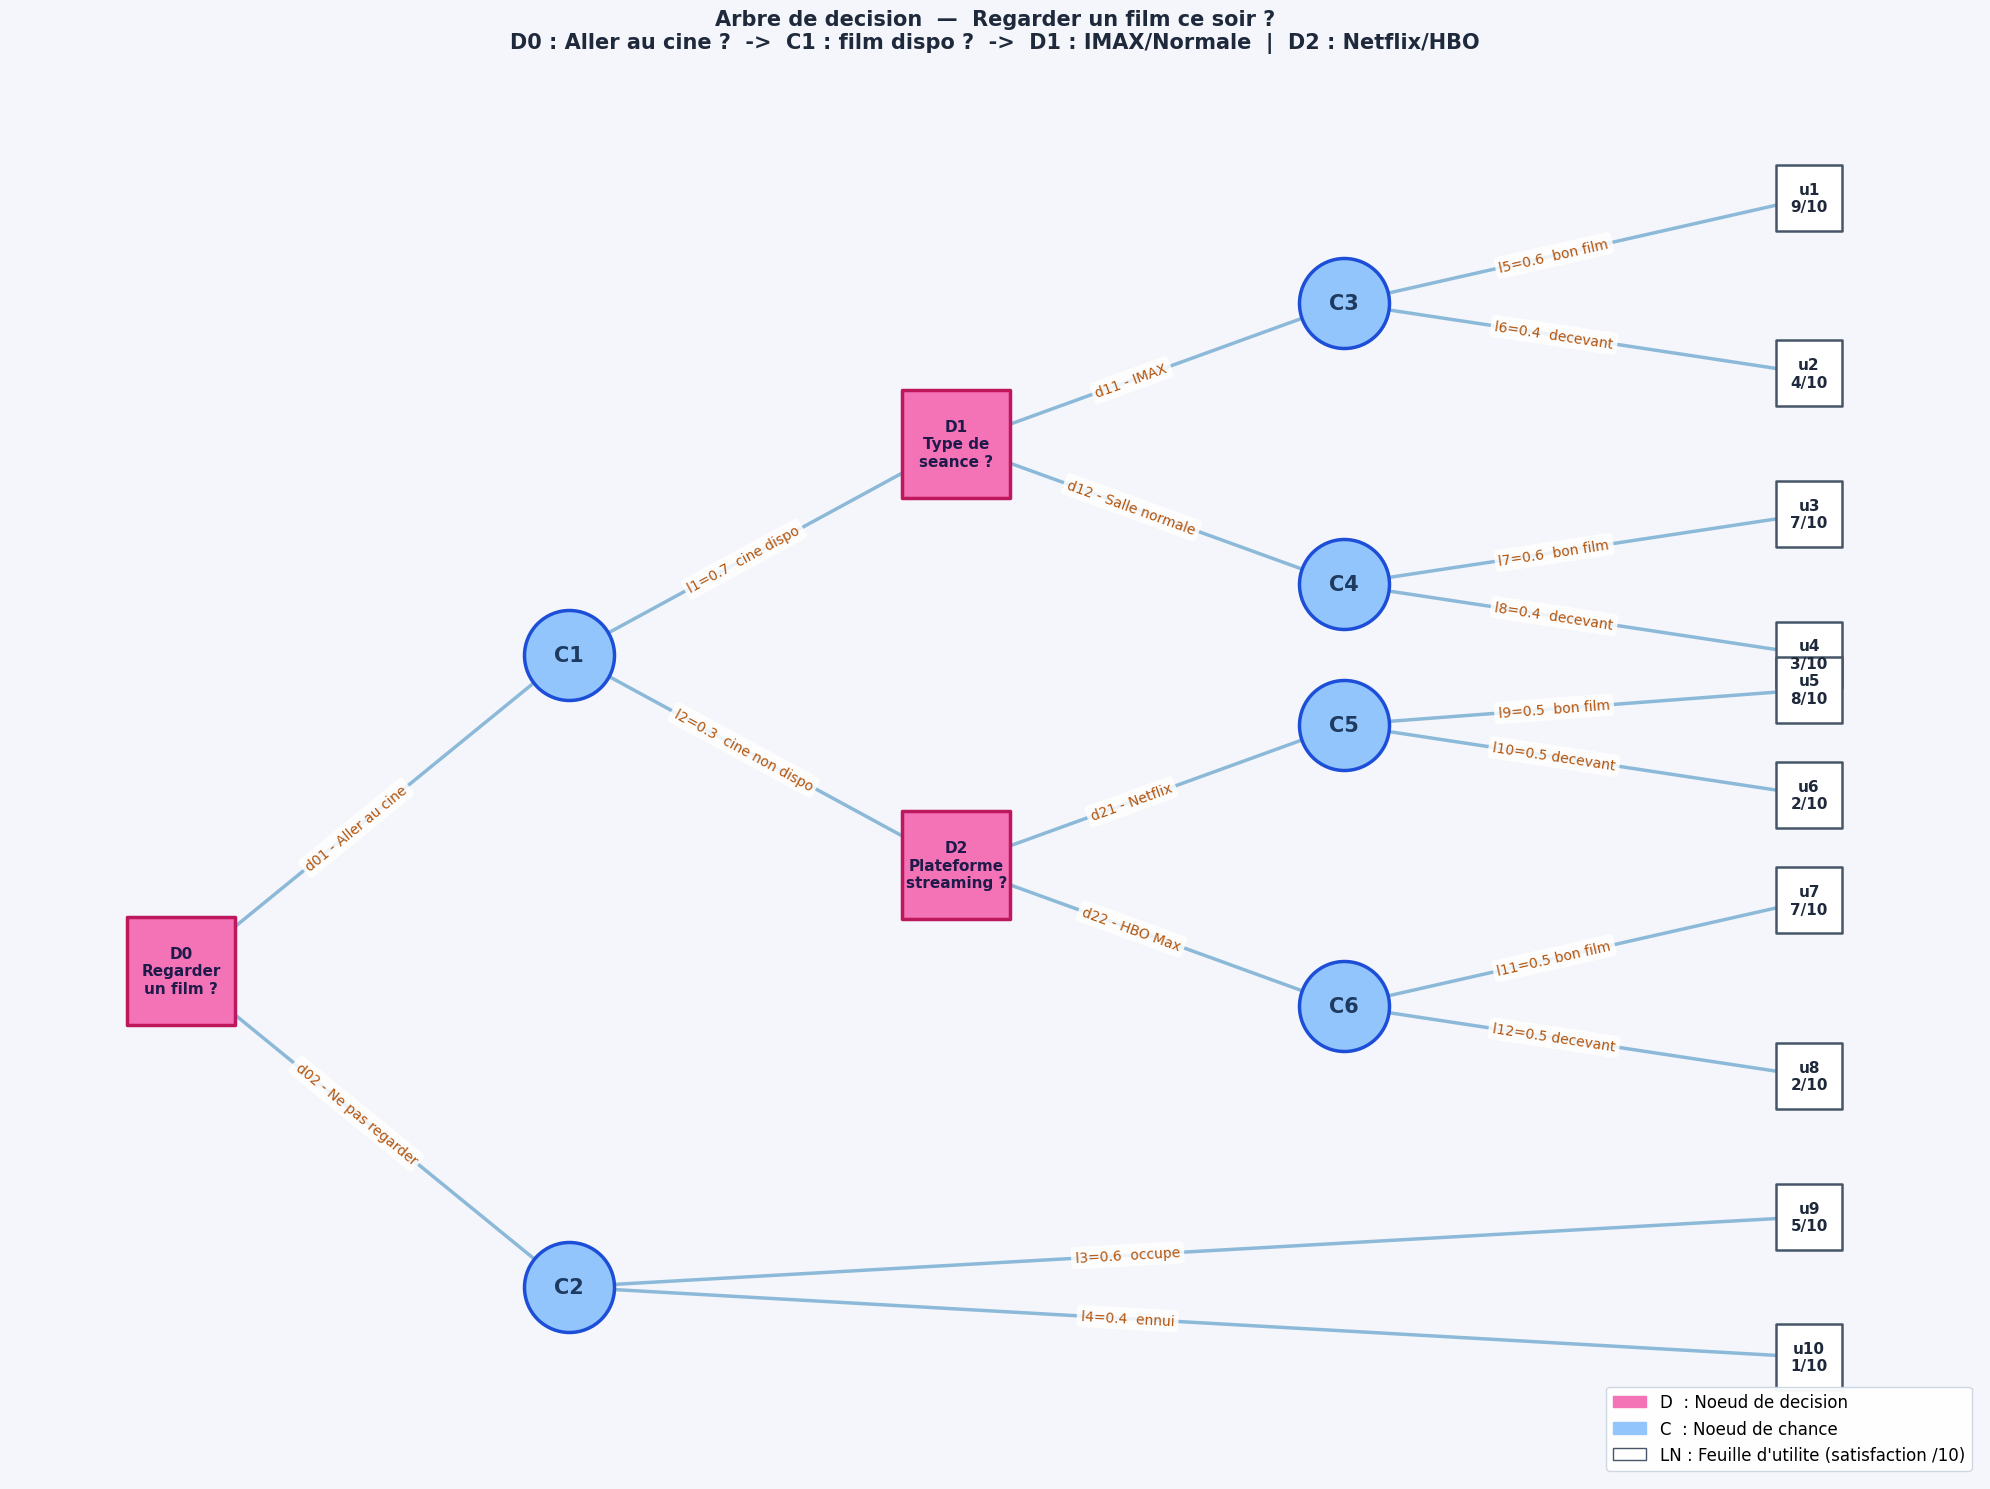


  Arbre de decision : les strategies
  Delta  D0              D1              D2            
  ----------------------------------------------------
  d1     d01 (cine)      d11 (IMAX)      d21 (Netflix) 
  d2     d01 (cine)      d11 (IMAX)      d22 (HBO)     
  d3     d01 (cine)      d12 (normale)   d21 (Netflix) 
  d4     d01 (cine)      d12 (normale)   d22 (HBO)     
  d5     d02 (non)       -               -             

  Notation ensembliste :
  d1 = {(D0,C1); (D1,C3); (D2,C5)}  -> cine + IMAX,    Netflix si pas dispo
  d2 = {(D0,C1); (D1,C3); (D2,C6)}  -> cine + IMAX,    HBO si pas dispo
  d3 = {(D0,C1); (D1,C4); (D2,C5)}  -> cine + normale, Netflix si pas dispo
  d4 = {(D0,C1); (D1,C4); (D2,C6)}  -> cine + normale, HBO si pas dispo
  d5 = {(D0,C2)}                     -> ne pas regarder de film


In [2]:
"""
  ARBRE DE DECISION — "Regarder un film ce soir ?"

Structure de l'arbre :
  D0  →  d01 : aller au cine   →  C1 (film dispo ?)
             →  dispo (0.7)    →  D1 (IMAX ou salle normale)
             →  pas dispo(0.3) →  D2 (Netflix ou HBO)
  D0  →  d02 : ne pas regarder →  C2 (occupe ou ennui)

Rappel des 3 types de noeuds :
  D  = noeud de Decision  (carre rose)   → le decideur choisit
  C  = noeud de Chance    (cercle bleu)  → la nature choisit
  LN = Feuille d'utilite  (carre blanc)  → satisfaction /10
"""

import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# 1. CREATION DU GRAPHE
G = nx.DiGraph()

# --- Noeuds de Decision D ---
decisions = {
    "D0": "D0\nRegarder\nun film ?",
    "D1": "D1\nType de\nseance ?",
    "D2": "D2\nPlateforme\nstreaming ?",
}

# --- Noeuds de Chance C ---
# C1 : dispo au cine ?  C2 : occupe ou ennui ?  C3-C6 : bon film ?
chances = {
    "C1": "C1", "C2": "C2",
    "C3": "C3", "C4": "C4",
    "C5": "C5", "C6": "C6",
}

# --- Feuilles d'utilite LN --- satisfaction /10
utilities = {
    "u1":  ("u1",  "9/10"),  # IMAX + bon film
    "u2":  ("u2",  "4/10"),  # IMAX + film nul
    "u3":  ("u3",  "7/10"),  # Normale + bon film
    "u4":  ("u4",  "3/10"),  # Normale + film nul
    "u5":  ("u5",  "8/10"),  # Netflix + bon film
    "u6":  ("u6",  "2/10"),  # Netflix + film nul
    "u7":  ("u7",  "7/10"),  # HBO + bon film
    "u8":  ("u8",  "2/10"),  # HBO + film nul
    "u9":  ("u9",  "5/10"),  # Pas de film + occupe
    "u10": ("u10", "1/10"),  # Pas de film + ennui
}

# 2. AJOUT DES NOEUDS
for k in decisions: G.add_node(k)
for k in chances:   G.add_node(k)
for k in utilities: G.add_node(k)

# 3. ARETES — type "d" = decision du joueur  /  type "p" = probabilite (nature)
edges = [
    ("D0", "C1", "d01 - Aller au cine",   "d"),
    ("D0", "C2", "d02 - Ne pas regarder", "d"),

    ("C1", "D1", "l1=0.7  cine dispo",     "p"),
    ("C1", "D2", "l2=0.3  cine non dispo", "p"),

    ("D1", "C3", "d11 - IMAX",         "d"),
    ("D1", "C4", "d12 - Salle normale", "d"),

    ("D2", "C5", "d21 - Netflix", "d"),
    ("D2", "C6", "d22 - HBO Max", "d"),

    ("C3", "u1",  "l5=0.6  bon film", "p"),
    ("C3", "u2",  "l6=0.4  decevant", "p"),
    ("C4", "u3",  "l7=0.6  bon film", "p"),
    ("C4", "u4",  "l8=0.4  decevant", "p"),
    ("C5", "u5",  "l9=0.5  bon film", "p"),
    ("C5", "u6",  "l10=0.5 decevant", "p"),
    ("C6", "u7",  "l11=0.5 bon film", "p"),
    ("C6", "u8",  "l12=0.5 decevant", "p"),
    ("C2", "u9",  "l3=0.6  occupe",   "p"),
    ("C2", "u10", "l4=0.4  ennui",    "p"),
]

for src, tgt, lbl, kind in edges:
    G.add_edge(src, tgt, label=lbl, kind=kind)

# 4. POSITIONS — resserrees sur x, bien espacees sur y
pos = {
    "D0": (0,   0),

    "C1": (2.5,  4.5),
    "C2": (2.5, -4.5),

    "D1": (5,    7.5),
    "D2": (5,    1.5),

    "C3": (7.5,  9.5),
    "C4": (7.5,  5.5),
    "C5": (7.5,  3.5),
    "C6": (7.5, -0.5),

    "u1":  (10.5, 11.0),
    "u2":  (10.5,  8.5),
    "u3":  (10.5,  6.5),
    "u4":  (10.5,  4.5),
    "u5":  (10.5,  4.0),
    "u6":  (10.5,  2.5),
    "u7":  (10.5,  1.0),
    "u8":  (10.5, -1.5),
    "u9":  (10.5, -3.5),
    "u10": (10.5, -5.5),
}

# 5. DESSIN
fig, ax = plt.subplots(figsize=(20, 15))
ax.set_facecolor("#f4f6fb")
fig.patch.set_facecolor("#f4f6fb")

# aretes
nx.draw_networkx_edges(G, pos, ax=ax,
    edge_color="#7bafd4", arrows=False, width=2.5, alpha=0.85)

# carres roses = decisions
nx.draw_networkx_nodes(G, pos, nodelist=list(decisions.keys()), ax=ax,
    node_shape="s", node_color="#f472b6",
    node_size=6000, linewidths=2.5, edgecolors="#be185d")

# cercles bleus = chance
nx.draw_networkx_nodes(G, pos, nodelist=list(chances.keys()), ax=ax,
    node_shape="o", node_color="#93c5fd",
    node_size=4200, linewidths=2.5, edgecolors="#1d4ed8")

# petits carres blancs = feuilles utilite
nx.draw_networkx_nodes(G, pos, nodelist=list(utilities.keys()), ax=ax,
    node_shape="s", node_color="white",
    node_size=2200, linewidths=1.8, edgecolors="#475569")

# labels noeuds decision
nx.draw_networkx_labels(G, pos,
    labels={k: decisions[k] for k in decisions}, ax=ax,
    font_size=11, font_color="#1e1b4b", font_weight="bold")

# labels noeuds chance
nx.draw_networkx_labels(G, pos,
    labels={k: chances[k] for k in chances}, ax=ax,
    font_size=15, font_color="#1e3a5f", font_weight="bold")

# labels feuilles
nx.draw_networkx_labels(G, pos,
    labels={k: f"{utilities[k][0]}\n{utilities[k][1]}" for k in utilities},
    ax=ax, font_size=11, font_color="#1e293b", font_weight="bold")

# etiquettes sur les aretes
edge_labels = {(s, t): lbl for s, t, lbl, _ in edges}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, ax=ax,
    font_size=10, font_color="#b45309",
    bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.85, ec="none"),
    label_pos=0.45)

# 6. LEGENDE ET TITRE
legend_patches = [
    mpatches.Patch(color="#f472b6", label="D  : Noeud de decision"),
    mpatches.Patch(color="#93c5fd", label="C  : Noeud de chance"),
    mpatches.Patch(facecolor="white", edgecolor="#475569",
                   label="LN : Feuille d'utilite (satisfaction /10)"),
]
ax.legend(handles=legend_patches, loc="lower right",
          fontsize=12, framealpha=0.95, edgecolor="#cbd5e1")

ax.set_title(
    "Arbre de decision  —  Regarder un film ce soir ?\n"
    "D0 : Aller au cine ?  ->  C1 : film dispo ?  "
    "->  D1 : IMAX/Normale  |  D2 : Netflix/HBO",
    fontsize=15, fontweight="bold", color="#1e293b", pad=20)

ax.axis("off")
plt.tight_layout()
plt.show()

# 7. STRATEGIES DELTA
# Une strategie = un choix pour chaque noeud de decision rencontre
# d1 a d4 : on essaie d'aller au cine (avec plan B streaming)
# d5      : on ne regarde rien du tout

print("\n==============================================")
print("  Arbre de decision : les strategies")
print("==============================================")

strategies = [
    ("d1", "d01 (cine)", "d11 (IMAX)",    "d21 (Netflix)"),
    ("d2", "d01 (cine)", "d11 (IMAX)",    "d22 (HBO)   "),
    ("d3", "d01 (cine)", "d12 (normale)", "d21 (Netflix)"),
    ("d4", "d01 (cine)", "d12 (normale)", "d22 (HBO)   "),
    ("d5", "d02 (non)",  "-",             "-           "),
]

print(f"  {'Delta':5}  {'D0':14}  {'D1':14}  {'D2':14}")
print("  " + "-"*52)
for row in strategies:
    print(f"  {row[0]:5}  {row[1]:14}  {row[2]:14}  {row[3]:14}")

print("\n  Notation ensembliste :")
notations = [
    ("d1", "{(D0,C1); (D1,C3); (D2,C5)}  -> cine + IMAX,    Netflix si pas dispo"),
    ("d2", "{(D0,C1); (D1,C3); (D2,C6)}  -> cine + IMAX,    HBO si pas dispo"),
    ("d3", "{(D0,C1); (D1,C4); (D2,C5)}  -> cine + normale, Netflix si pas dispo"),
    ("d4", "{(D0,C1); (D1,C4); (D2,C6)}  -> cine + normale, HBO si pas dispo"),
    ("d5", "{(D0,C2)}                     -> ne pas regarder de film"),
]
for name, nota in notations:
    print(f"  {name} = {nota}")